In [1]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [3]:
# make the blobs: y contains the cluster IDs, but we will not use them; that's what we want to predict

X, y = make_blobs(n_samples=200, centers=3, n_features=2, random_state=42)

In [4]:
k = 5

In [5]:
kmeans = KMeans(n_clusters=k, random_state=42)

In [6]:
y_pred = kmeans.fit_predict(X)

In [7]:
y_pred

array([2, 3, 1, 1, 1, 1, 3, 1, 2, 1, 4, 2, 2, 4, 4, 1, 3, 1, 2, 1, 2, 4,
       1, 0, 1, 3, 3, 1, 0, 4, 4, 2, 1, 1, 3, 0, 1, 3, 1, 0, 4, 3, 1, 2,
       1, 2, 4, 1, 4, 0, 1, 3, 1, 0, 3, 3, 1, 4, 3, 4, 1, 3, 1, 1, 1, 1,
       3, 0, 1, 0, 0, 1, 0, 4, 0, 2, 4, 3, 2, 3, 0, 4, 4, 1, 1, 1, 1, 0,
       4, 1, 4, 3, 3, 0, 2, 1, 3, 2, 2, 0, 1, 1, 0, 1, 0, 4, 1, 4, 2, 1,
       2, 2, 0, 1, 3, 1, 1, 3, 3, 0, 1, 2, 3, 1, 1, 4, 3, 0, 4, 0, 2, 1,
       0, 1, 1, 2, 4, 2, 3, 2, 3, 3, 1, 4, 4, 3, 4, 1, 1, 4, 3, 1, 2, 1,
       4, 1, 1, 0, 2, 2, 3, 4, 2, 1, 3, 2, 4, 3, 1, 2, 1, 0, 4, 1, 0, 2,
       3, 3, 3, 4, 3, 4, 1, 1, 1, 0, 2, 2, 4, 3, 0, 4, 1, 1, 0, 1, 0, 0,
       4, 4], dtype=int32)

In [8]:
y_pred is kmeans.labels_

True

In [9]:
kmeans.cluster_centers_

array([[-2.0210392 ,  8.3637459 ],
       [-6.74539381, -6.85144337],
       [ 5.50592911,  2.41148373],
       [-3.1759419 ,  9.43904577],
       [ 3.87978917,  1.83403686]])

In [10]:
import numpy as np

In [11]:
X_new = np.array([[0, 2], [3, 2], [-3, 3], [-3, 2.5]])

In [12]:
kmeans.predict(X_new)

array([4, 4, 0, 0], dtype=int32)

In [13]:
kmeans.transform(X_new).round(2)

array([[ 6.68, 11.13,  5.52,  8.09,  3.88],
       [ 8.11, 13.17,  2.54,  9.67,  0.9 ],
       [ 5.45, 10.54,  8.53,  6.44,  6.98],
       [ 5.94, 10.07,  8.51,  6.94,  6.91]])

# Clustering using image segmentation


In [8]:
from PIL import Image
from pathlib import Path
import numpy as np

In [4]:
filepath = Path.joinpath(Path.absolute(Path(".")), "image1.jpg")

In [9]:
image = np.asarray(Image.open(filepath))

In [10]:
image.shape

(350, 642, 3)

In [11]:
X = image.reshape(-1, 3)

In [13]:
from sklearn.cluster import KMeans

In [14]:
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)

In [15]:
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img

array([[ 56.35171145,  91.35646669,  18.2741406 ],
       [ 56.35171145,  91.35646669,  18.2741406 ],
       [ 56.35171145,  91.35646669,  18.2741406 ],
       ...,
       [210.6385192 , 220.85902227, 226.03966433],
       [210.6385192 , 220.85902227, 226.03966433],
       [210.6385192 , 220.85902227, 226.03966433]], shape=(224700, 3))

In [16]:
segmented_img = segmented_img.reshape(image.shape)
segmented_img

array([[[ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        ...,
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ]],

       [[ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        ...,
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ]],

       [[ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        ...,
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ],
        [ 56.35171145,  91.35646669,  18.2741406 ]],

       ...,

      

# Using Clustering for Semi-Supervised Learning


In [17]:
from sklearn.datasets import load_digits

In [18]:
X_digits, y_digits = load_digits(return_X_y=True)

In [19]:
X_train, y_train = X_digits[:1400], y_digits[:1400]
X_test, y_test = X_digits[1400:], y_digits[1400:]

In [20]:
from sklearn.linear_model import LogisticRegression

In [21]:
n_labeled = 50

In [22]:
log_reg = LogisticRegression(max_iter=10_000)

In [23]:
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [24]:
log_reg.score(X_test, y_test)

0.7581863979848866

In [25]:
k = 50

In [26]:
kmeans = KMeans(n_clusters=k, random_state=42)

In [27]:
X_digits_dist = kmeans.fit_transform(X_train)

In [28]:
representative_digit_idx = X_digits_dist.argmin(axis=0)

In [29]:
X_representative_digits = X_train[representative_digit_idx]

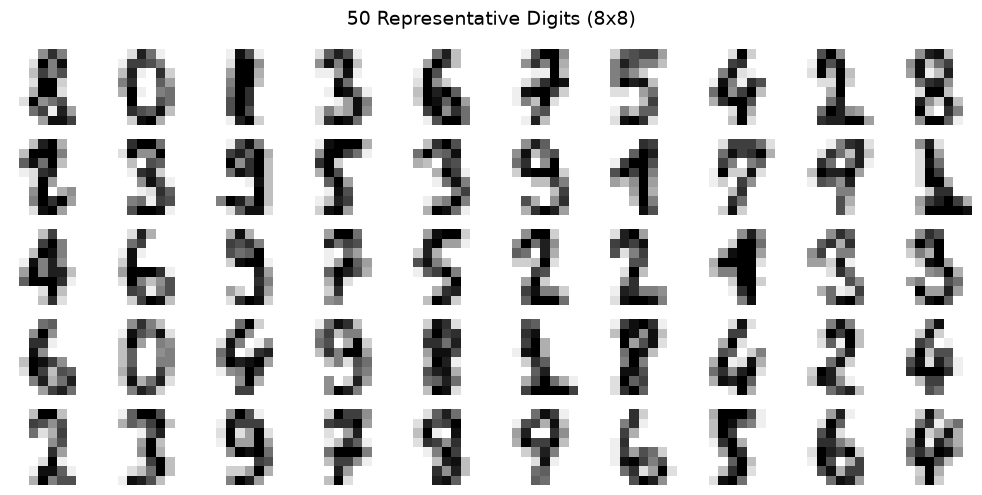

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for index, X_digit in enumerate(X_representative_digits):
    plt.subplot(5, 10, index + 1)

    # Reshape from 64 elements to an 8x8 image
    plt.imshow(X_digit.reshape(8, 8), cmap="binary")

    plt.axis("off")

plt.suptitle("50 Representative Digits (8x8)", fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
y_representative_digits = np.array(
    [
        8,
        0,
        1,
        3,
        6,
        7,
        5,
        4,
        2,
        8,
        2,
        3,
        9,
        5,
        3,
        9,
        1,
        7,
        9,
        1,
        4,
        6,
        9,
        7,
        5,
        2,
        2,
        1,
        3,
        3,
        6,
        0,
        4,
        9,
        8,
        1,
        8,
        4,
        2,
        4,
        2,
        3,
        9,
        7,
        8,
        9,
        6,
        5,
        6,
        4,
    ]
)

In [33]:
log_reg = LogisticRegression(max_iter=10_000)

In [34]:
log_reg.fit(X_representative_digits, y_representative_digits)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",10000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 

In [35]:
log_reg.score(X_test, y_test)

0.8337531486146096

In [36]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)

In [37]:
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]

In [38]:
y_train_propagated

array([0, 1, 2, ..., 4, 4, 7], shape=(1400,))

In [39]:
log_reg = LogisticRegression(random_state=42, max_iter=10000)
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.871536523929471

In [40]:
percentile_closest = 50

In [41]:
X_cluster_dist = X_digits_dist[np.arange(len(X_train)), kmeans.labels_]

In [42]:
for i in range(k):
    in_cluster = kmeans.labels_ == i
    cluster_dist = X_cluster_dist[in_cluster]
    cutoff_distance = np.percentile(cluster_dist, percentile_closest)
    above_cutoff = X_cluster_dist > cutoff_distance
    X_cluster_dist[in_cluster & above_cutoff] = -1
partially_propagated = X_cluster_dist != -1
X_train_partially_propagated = X_train[partially_propagated]
y_train_partially_propagated = y_train_propagated[partially_propagated]

In [43]:
log_reg = LogisticRegression(max_iter=10_000, random_state=42)
log_reg.fit(X_train_partially_propagated, y_train_partially_propagated)
log_reg.score(X_test, y_test)

0.8841309823677582

In [45]:
(y_train_partially_propagated == y_train[partially_propagated]).mean()

np.float64(0.9887798036465638)